# Libraries

In [1]:
# Data Preparation
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
# Data Preprocessing
from transformers import AutoTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
import nltk
import string

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Data Visualization
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

from tqdm import tqdm

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Device

In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


# Data Preprocessing & Preparation

In [19]:
stop_words_list = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

# from transformers import AutoTokenizer, AutoModel
# # Load RoBERTa tokenizer and model
# tokenizer = AutoTokenizer.from_pretrained("roberta-base")
# model = AutoModel.from_pretrained("roberta-base")

from transformers import RobertaTokenizer
from transformers import AutoModelForSequenceClassification
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

def embedding(sentences, max_len=64):
    """
    Tokenize and encode sentences into DeBERTa embeddings.
    """
    # Tokenize input
    inputs = tokenizer(sentences, return_tensors='pt', padding=True, truncation=True, max_length=max_len)

    # Get DeBERTa embeddings
    with torch.no_grad():
        outputs = model(**inputs)

    # Extract [CLS]-like token (DeBERTa uses first token)
    # return outputs.last_hidden_state[:, 0, :]
    return outputs.logits  # Use logits, not last_hidden_state

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

# Preprocessing pipelien
transform_pipeline = preprocessing.Compose([
    preprocessing.Lowercase()
    #preprocessing.Tokenize(tokenizer),
    #preprocessing.StopwordsRemoval(stop_words_list),
    #preprocessing.POStagging(),
    #preprocessing.Lemmatization(lemmatizer), 
])

In [22]:
# 1. Load dataset and apply prior Transform 
train_dataset = IMDBDataset(base_path='aclImdb', size=2000, train=True, transform=transform_pipeline)
test_dataset = IMDBDataset(base_path='aclImdb', size=1000, train=False, transform=transform_pipeline)
print(train_dataset.df.head())

# 2. Extract preprocessed texts and labels
train_input = [train_dataset[i][0] for i in range(len(train_dataset))]
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]

test_input = [test_dataset[i][0] for i in range(len(test_dataset))]
test_labels = [test_dataset[i][1] for i in range(len(test_dataset))]

# 3. Apply BERT Embeddings to the whole dataset
train_embedded_features = embedding(train_input)
test_embedded_features = embedding(test_input)

# 4. Convert to PyTorch tensors
X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
y_train_tensor = torch.tensor(train_labels, dtype=torch.long)

X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)
y_test_tensor = torch.tensor(test_labels, dtype=torch.long)

# 5. Construct dataset for dataloader
train_dataset = torch.utils.data.TensorDataset(train_embedded_features, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(test_embedded_features, y_test_tensor)

     id                                             review  score sentiment
0  2214  My family goes back to New Orleans late 1600's...     10  positive
1  7034  when you add up all the aspects from the movie...     10  positive
2  9919  Mesmerizing, breathtaking and horrifying, this...      9  positive
3  6850  Dressed to Kill starts off with Kate Miller (A...      7  positive
4  4405  The War Between the States was perhaps the dar...      8  positive


/var/folders/hs/jhbbsd052zz044qtbzkkhxl80000gn/T/ipykernel_27490/3393106566.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
/var/folders/hs/jhbbsd052zz044qtbzkkhxl80000gn/T/ipykernel_27490/3393106566.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)


# Split data for training and validation

In [ ]:
# Split train_dataset into training and validation set
from sklearn.model_selection import train_test_split

#Split dataset for train and validation
train_size = int(0.8 * len(train_dataset))
train_indices, val_indices = train_test_split(list(range(len(train_dataset))),
                                              test_size=len(train_dataset) - train_size,
                                              stratify=y_train_tensor,
                                              random_state=42)

trainset = torch.utils.data.Subset(train_dataset, train_indices)
valset = torch.utils.data.Subset(train_dataset, val_indices)

#DataLoader to handle batching and shuffling
batch_size = 32
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

# Model

# Training + Evaluation

In [ ]:
from train_test import train_model, test_model, plot_accuracy_loss, plot_confusion_matrix
import classifier as clf

# init paramètre
nb_epochs = 64
optimizer = 'Adam'
lr = 0.001

SimpleClassifier(
  (fc1): Linear(in_features=768, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


38552 total parameters.
38552 training parameters.




  6%|▋         | 4/64 [00:00<00:05, 11.14it/s]

| Epoch: [1/64] | Train: Loss 0.6906 Accuracy : 0.5200 | Val: Loss 0.6827 Accuracy : 0.5100

| Epoch: [2/64] | Train: Loss 0.6725 Accuracy : 0.5925 | Val: Loss 0.6660 Accuracy : 0.5275

| Epoch: [3/64] | Train: Loss 0.6398 Accuracy : 0.6781 | Val: Loss 0.6277 Accuracy : 0.6100

| Epoch: [4/64] | Train: Loss 0.5949 Accuracy : 0.7238 | Val: Loss 0.5819 Accuracy : 0.7000

| Epoch: [5/64] | Train: Loss 0.5533 Accuracy : 0.7462 | Val: Loss 0.5390 Accuracy : 0.7500

| Epoch: [6/64] | Train: Loss 0.5227 Accuracy : 0.7650 | Val: Loss 0.5116 Accuracy : 0.7800

| Epoch: [7/64] | Train: Loss 0.5013 Accuracy : 0.7800 | Val: Loss 0.4943 Accuracy : 0.7800



 19%|█▉        | 12/64 [00:00<00:02, 24.20it/s]

| Epoch: [8/64] | Train: Loss 0.4859 Accuracy : 0.7850 | Val: Loss 0.4833 Accuracy : 0.7825

| Epoch: [9/64] | Train: Loss 0.4744 Accuracy : 0.7900 | Val: Loss 0.4763 Accuracy : 0.7925

| Epoch: [10/64] | Train: Loss 0.4653 Accuracy : 0.7913 | Val: Loss 0.4719 Accuracy : 0.7950

| Epoch: [11/64] | Train: Loss 0.4578 Accuracy : 0.7969 | Val: Loss 0.4691 Accuracy : 0.7925

| Epoch: [12/64] | Train: Loss 0.4515 Accuracy : 0.7981 | Val: Loss 0.4675 Accuracy : 0.7950

| Epoch: [13/64] | Train: Loss 0.4459 Accuracy : 0.8019 | Val: Loss 0.4666 Accuracy : 0.7950

| Epoch: [14/64] | Train: Loss 0.4411 Accuracy : 0.8050 | Val: Loss 0.4665 Accuracy : 0.7925

| Epoch: [15/64] | Train: Loss 0.4368 Accuracy : 0.8075 | Val: Loss 0.4669 Accuracy : 0.7850



...

| Epoch: [41/64] | Train: Loss 0.3680 Accuracy : 0.8506 | Val: Loss 0.5079 Accuracy : 0.7775

| Epoch: [42/64] | Train: Loss 0.3659 Accuracy : 0.8519 | Val: Loss 0.5101 Accuracy : 0.7725

| Epoch: [43/64] | Train: Loss 0.3637 Accuracy : 0.8519 | Val: Loss 0.5117 Accuracy : 0.7700

| Epoch: [44/64] | Train: Loss 0.3617 Accuracy : 0.8544 | Val: Loss 0.5141 Accuracy : 0.7675

| Epoch: [45/64] | Train: Loss 0.3597 Accuracy : 0.8550 | Val: Loss 0.5169 Accuracy : 0.7700

| Epoch: [46/64] | Train: Loss 0.3573 Accuracy : 0.8556 | Val: Loss 0.5199 Accuracy : 0.7725

| Epoch: [47/64] | Train: Loss 0.3551 Accuracy : 0.8581 | Val: Loss 0.5208 Accuracy : 0.7725

| Epoch: [48/64] | Train: Loss 0.3531 Accuracy : 0.8594 | Val: Loss 0.5237 Accuracy : 0.7750

| Epoch: [49/64] | Train: Loss 0.3508 Accuracy : 0.8612 | Val: Loss 0.5255 Accuracy : 0.7750



 88%|████████▊ | 56/64 [00:01<00:00, 41.10it/s]

| Epoch: [50/64] | Train: Loss 0.3489 Accuracy : 0.8619 | Val: Loss 0.5279 Accuracy : 0.7725

| Epoch: [51/64] | Train: Loss 0.3464 Accuracy : 0.8619 | Val: Loss 0.5293 Accuracy : 0.7750

| Epoch: [52/64] | Train: Loss 0.3445 Accuracy : 0.8612 | Val: Loss 0.5319 Accuracy : 0.7700

| Epoch: [53/64] | Train: Loss 0.3424 Accuracy : 0.8625 | Val: Loss 0.5358 Accuracy : 0.7700

| Epoch: [54/64] | Train: Loss 0.3402 Accuracy : 0.8625 | Val: Loss 0.5390 Accuracy : 0.7700

| Epoch: [55/64] | Train: Loss 0.3381 Accuracy : 0.8662 | Val: Loss 0.5389 Accuracy : 0.7650

| Epoch: [56/64] | Train: Loss 0.3365 Accuracy : 0.8656 | Val: Loss 0.5438 Accuracy : 0.7650

| Epoch: [57/64] | Train: Loss 0.3341 Accuracy : 0.8675 | Val: Loss 0.5448 Accuracy : 0.7650

| Epoch: [58/64] | Train: Loss 0.3320 Accuracy : 0.8675 | Val: Loss 0.5483 Accuracy : 0.7650



100%|██████████| 64/64 [00:01<00:00, 32.30it/s]

| Epoch: [59/64] | Train: Loss 0.3298 Accuracy : 0.8669 | Val: Loss 0.5500 Accuracy : 0.7650

| Epoch: [60/64] | Train: Loss 0.3282 Accuracy : 0.8675 | Val: Loss 0.5535 Accuracy : 0.7650

| Epoch: [61/64] | Train: Loss 0.3257 Accuracy : 0.8675 | Val: Loss 0.5540 Accuracy : 0.7650

| Epoch: [62/64] | Train: Loss 0.3239 Accuracy : 0.8681 | Val: Loss 0.5553 Accuracy : 0.7650

| Epoch: [63/64] | Train: Loss 0.3219 Accuracy : 0.8694 | Val: Loss 0.5594 Accuracy : 0.7650

| Epoch: [64/64] | Train: Loss 0.3195 Accuracy : 0.8719 | Val: Loss 0.5600 Accuracy : 0.7625


Test accuracy: 0.752


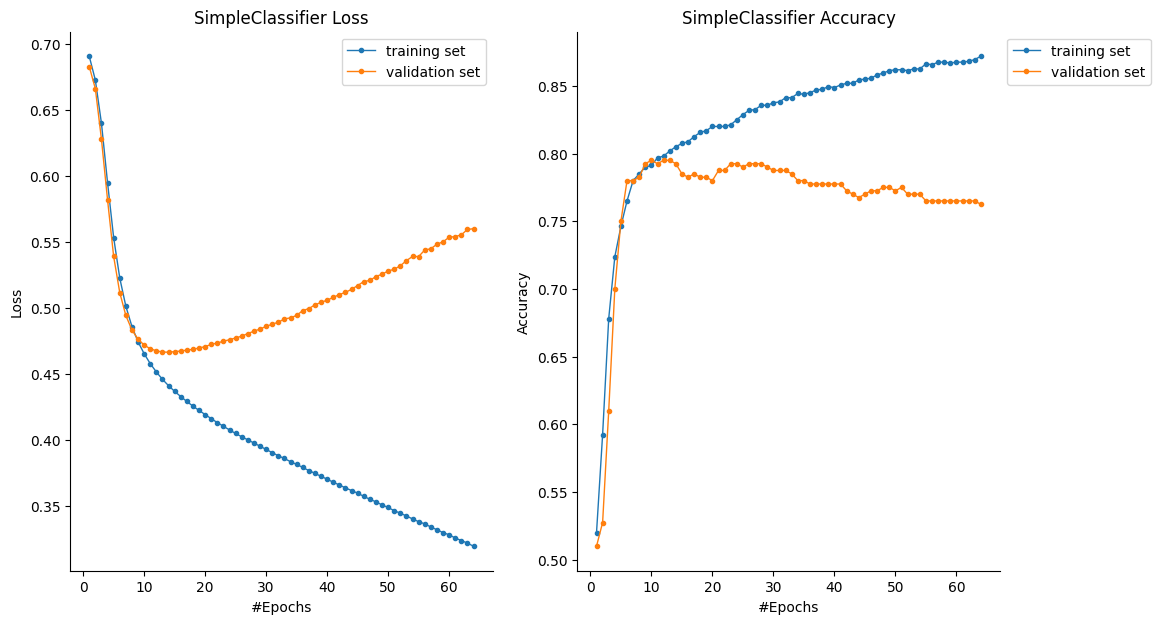

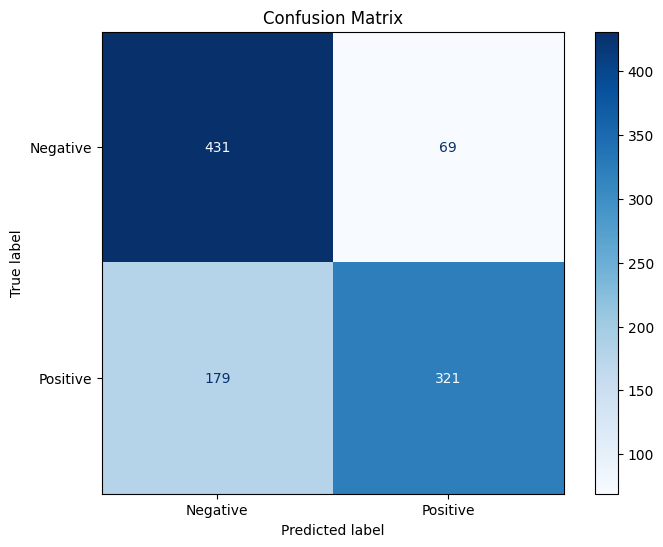

In [ ]:
input_dim = train_dataset.tensors[0].shape[1]
model = clf.SimpleClassifier(input_dim=input_dim).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("SimpleClassifier", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# LSTM

LSTMClassifier(
  (lstm): LSTM(768, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


592130 total parameters.
592130 training parameters.




  2%|▏         | 1/64 [00:00<00:08,  7.53it/s]

| Epoch: [1/64] | Train: Loss 0.6941 Accuracy : 0.4888 | Val: Loss 0.6904 Accuracy : 0.5450



  3%|▎         | 2/64 [00:00<00:09,  6.56it/s]

| Epoch: [2/64] | Train: Loss 0.6784 Accuracy : 0.5531 | Val: Loss 0.6756 Accuracy : 0.5000



...

| Epoch: [62/64] | Train: Loss 0.0050 Accuracy : 1.0000 | Val: Loss 1.5897 Accuracy : 0.7675



 98%|█████████▊| 63/64 [00:08<00:00,  7.74it/s]

| Epoch: [63/64] | Train: Loss 0.0016 Accuracy : 1.0000 | Val: Loss 1.6196 Accuracy : 0.7650



100%|██████████| 64/64 [00:08<00:00,  7.25it/s]

| Epoch: [64/64] | Train: Loss 0.0016 Accuracy : 1.0000 | Val: Loss 1.6548 Accuracy : 0.7650


Test accuracy: 0.755


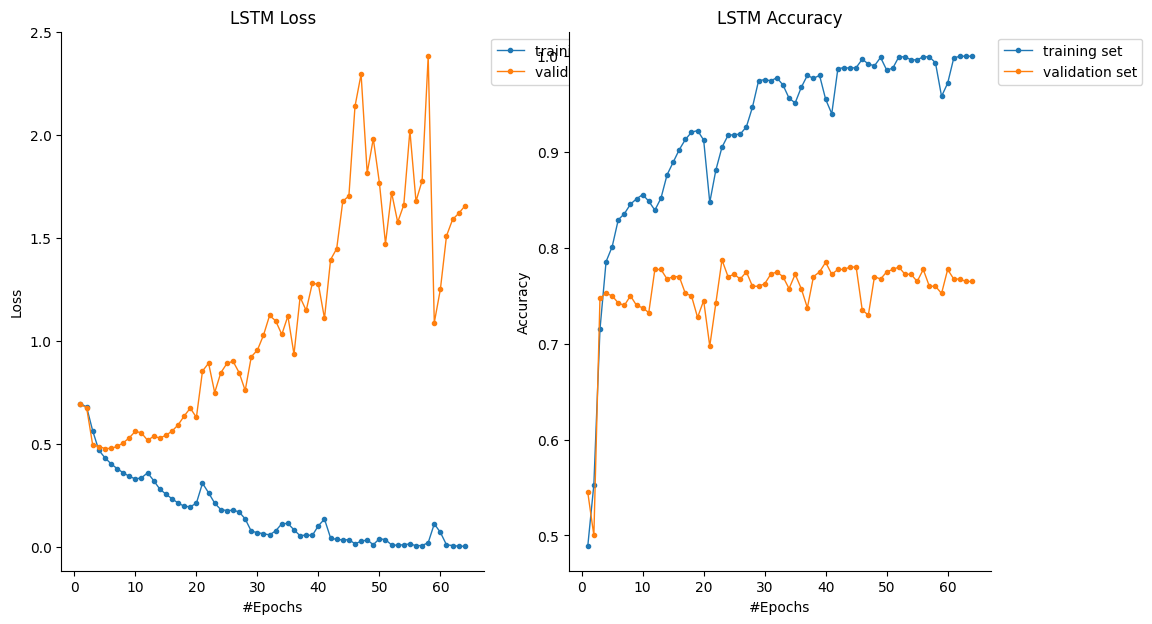

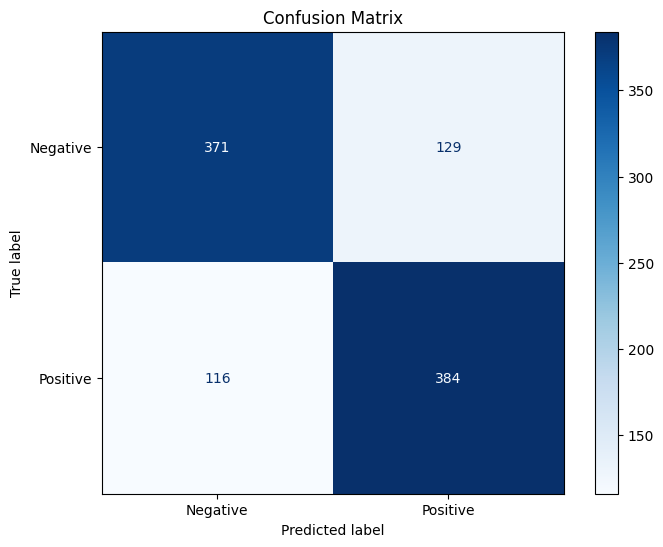

In [ ]:
input_dim = train_embedded_features.shape[1]  
model = clf.LSTMClassifier(input_dim=input_dim, hidden_dim=128, num_layers=2, output_dim=2, bidirectional=False).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("LSTM", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# Deeper LSTM

DeepLSTMClassifier(
  (lstm): LSTM(768, 128, num_layers=3, batch_first=True, dropout=0.4, bidirectional=True)
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1726658 total parameters.
1726658 training parameters.




  2%|▏         | 1/64 [00:00<00:24,  2.58it/s]

| Epoch: [1/64] | Train: Loss 0.6939 Accuracy : 0.5019 | Val: Loss 0.6927 Accuracy : 0.5000



  3%|▎         | 2/64 [00:00<00:21,  2.84it/s]

| Epoch: [2/64] | Train: Loss 0.6777 Accuracy : 0.5800 | Val: Loss 0.6347 Accuracy : 0.6425



...

| Epoch: [62/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.1355 Accuracy : 0.7750



 98%|█████████▊| 63/64 [00:22<00:00,  2.46it/s]

| Epoch: [63/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.1449 Accuracy : 0.7750



100%|██████████| 64/64 [00:23<00:00,  2.77it/s]

| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.1541 Accuracy : 0.7750


Test accuracy: 0.76


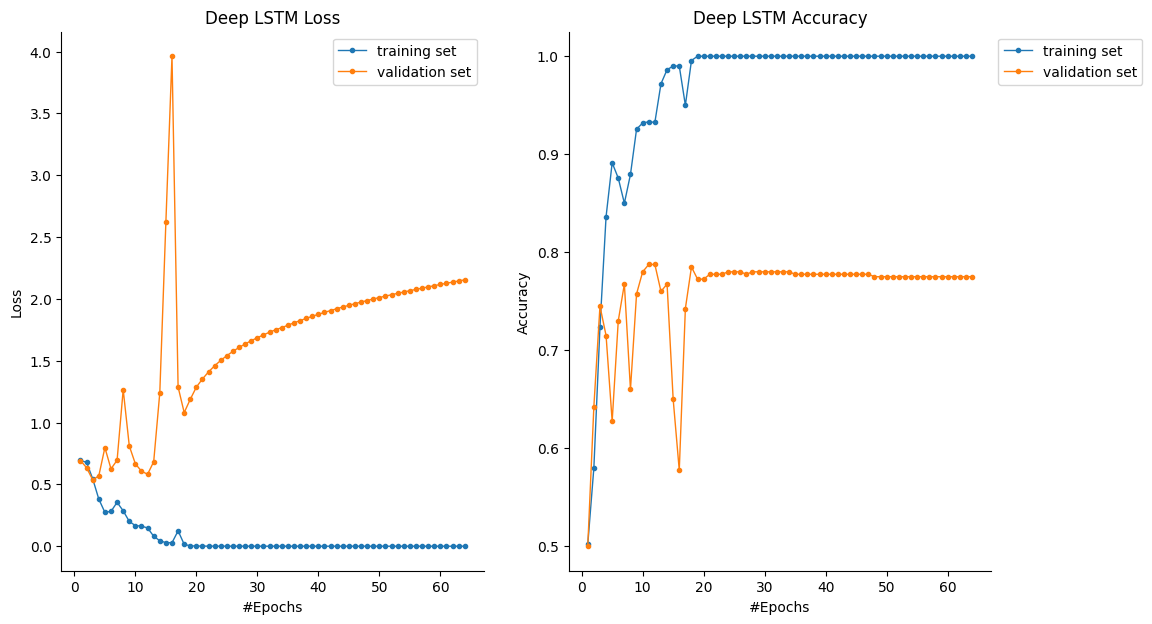

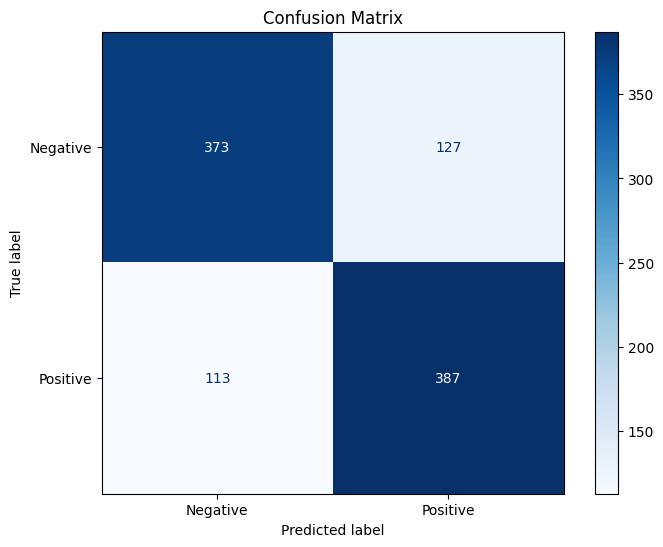

In [ ]:
input_dim = X_train_tensor.shape[1]  
model = clf.DeepLSTMClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=3,
    fc_hidden_dim=64,
    output_dim=2,  # set this to the number of classes
    dropout=0.4,
    bidirectional=True
).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Deep LSTM", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# Attention LSTM

LSTMWithAttentionClassifier(
  (lstm): LSTM(768, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1331651 total parameters.
1331651 training parameters.




  2%|▏         | 1/64 [00:00<00:22,  2.80it/s]

| Epoch: [1/64] | Train: Loss 0.6949 Accuracy : 0.4969 | Val: Loss 0.6918 Accuracy : 0.5825



  3%|▎         | 2/64 [00:00<00:19,  3.22it/s]

| Epoch: [2/64] | Train: Loss 0.6742 Accuracy : 0.5975 | Val: Loss 0.6039 Accuracy : 0.7025



...

| Epoch: [62/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 2.0427 Accuracy : 0.7900



 98%|█████████▊| 63/64 [00:18<00:00,  3.41it/s]

| Epoch: [63/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 2.0541 Accuracy : 0.7900



100%|██████████| 64/64 [00:18<00:00,  3.37it/s]

| Epoch: [64/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 2.0650 Accuracy : 0.7900


Test accuracy: 0.76


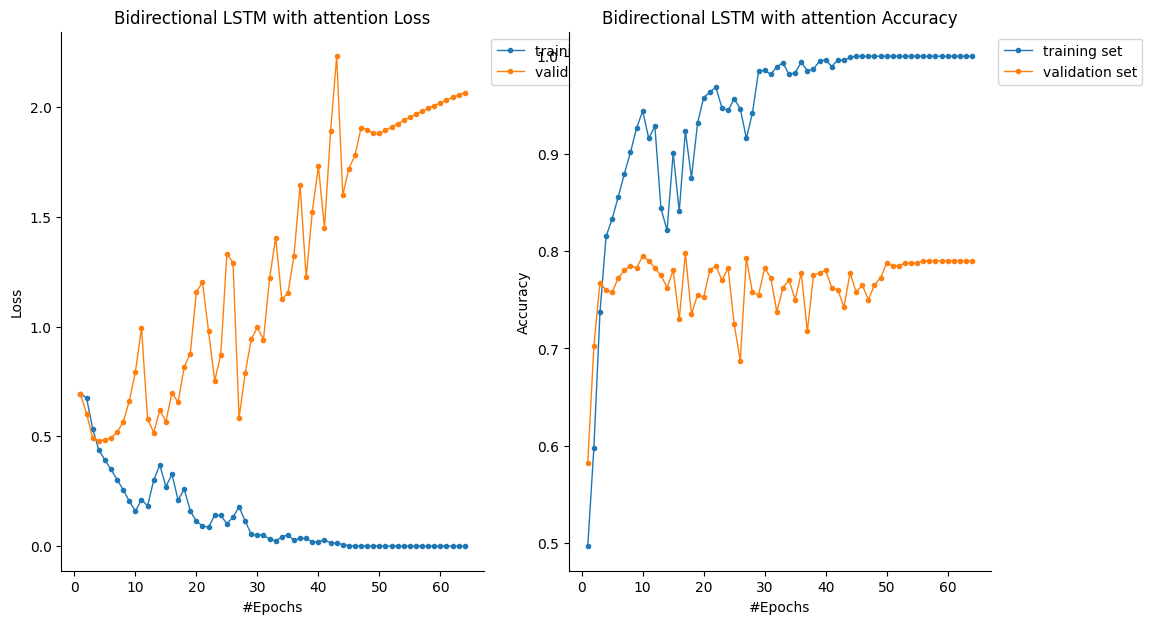

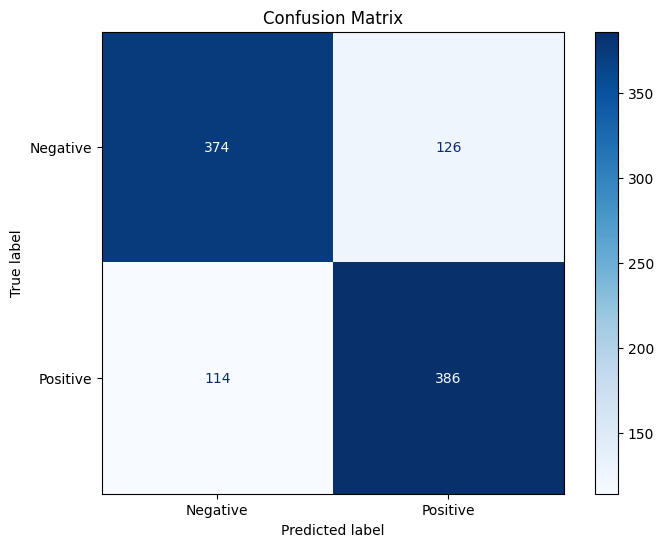

In [ ]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMWithAttentionClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=2,
    output_dim=2,
    dropout=0.3,
    fc_hidden_dim=64,
    bidirectional=True
).to(device)


print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Bidirectional LSTM with attention", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])